# GenAI Data Analyst Copilot

A Generative AI application that allows users to upload a CSV dataset,
explore its quality, ask business questions in natural language, and
receive analytical results and business insights.

## Technology Stack

- Google Colab
- Hugging Face Transformers
- Qwen2.5-3B-Instruct
- PyTorch
- Pandas
- Matplotlib
- Gradio

#Environment Setup

In [1]:
!pip install -q pandas==2.2.2 transformers accelerate "bitsandbytes>=0.46.1" gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import torch
import transformers
import gradio as gr

print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Pandas: 2.2.2
PyTorch: 2.11.0+cu128
Transformers: 5.12.1
CUDA available: True
GPU: Tesla T4


# Imports and Configuration

In [3]:
import json
import re

import gradio as gr
import matplotlib.pyplot as plt
import pandas as pd
import torch

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    pipeline,
)

MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


# Load the Hugging Face Model

In [4]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quantization_config,
    device_map="auto",
)

generator = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer,
)

print("Model loaded successfully.")

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded successfully.


# Test the Model

In [5]:
messages = [
    {
        "role": "system",
        "content": "You are a concise and accurate business data analyst.",
    },
    {
        "role": "user",
        "content": "Explain the purpose of sales trend analysis in three points.",
    },
]

prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

response = generator(
    prompt,
    max_new_tokens=150,
    do_sample=False,
    return_full_text=False,
)

print(response[0]["generated_text"])

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it 

Sales trend analysis serves several key purposes:

1. **Identifying Patterns and Predictions**: It helps identify patterns in sales performance over time, enabling forecasts for future sales trends. This aids in strategic planning and resource allocation.

2. **Improving Decision-Making**: By analyzing historical sales data, businesses can make informed decisions about pricing strategies, product development, and marketing efforts, leading to more effective business operations.

3. **Benchmarking Performance**: Sales trend analysis allows companies to compare their performance against industry benchmarks or competitors, providing insights into areas where they may be excelling or underperforming.


# Upload and Load Dataset

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd

file_path = "/content/drive/MyDrive/Colab Notebooks/complaints.csv"

df = pd.read_csv(
    file_path,
    nrows=50000
)

print(df.shape)

(50000, 18)


# Preprocessing

In [8]:
date_columns = [
    "Date received",
    "Date sent to company"
]

for column in date_columns:
    df[column] = pd.to_datetime(
        df[column],
        errors="coerce"
    )

In [9]:
before_rows = len(df)

df = df.drop_duplicates().copy()

after_rows = len(df)

print("Rows before:", before_rows)
print("Rows after:", after_rows)
print("Duplicates removed:", before_rows - after_rows)

Rows before: 50000
Rows after: 50000
Duplicates removed: 0


In [10]:
df["Year received"] = df["Date received"].dt.year
df["Month received"] = df["Date received"].dt.to_period("M").astype(str)

df["Days to company"] = (
    df["Date sent to company"] - df["Date received"]
).dt.days

In [11]:
quality_report = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    ).round(2),
    "Unique Values": df.nunique()
})

quality_report

,Data Type,Missing Values,Missing Percentage,Unique Values
Date received,datetime64[ns],0,0.00,4404
Product,object,0,0.00,20
Sub-product,object,770,1.54,79
Issue,object,0,0.00,156
Sub-issue,object,3129,6.26,236
Consumer complaint narrative,object,36893,73.79,11359
Company public response,object,22889,45.78,11
Company,object,0,0.00,1232
State,object,226,0.45,59
ZIP code,object,120,0.24,9799


In [12]:
narrative_count = df[
    "Consumer complaint narrative"
].notna().sum()

narrative_percentage = (
    narrative_count / len(df) * 100
)

print("Narratives available:", narrative_count)
print(
    "Narrative availability:",
    round(narrative_percentage, 2),
    "%"
)

Narratives available: 13107
Narrative availability: 26.21 %


# Build the AI functionality

In [13]:
def get_complaints_by_company(df, company_name, limit=20):
    complaints = (
        df[
            (df["Company"] == company_name)
            & (df["Consumer complaint narrative"].notna())
        ]["Consumer complaint narrative"]
        .head(limit)
        .tolist()
    )

    return complaints

In [14]:
df["Company"].value_counts().head(10)

,count
Company,
"TRANSUNION INTERMEDIATE HOLDINGS, INC.",13206
"EQUIFAX, INC.",13030
Experian Information Solutions Inc.,11620
"BANK OF AMERICA, NATIONAL ASSOCIATION",603
WELLS FARGO & COMPANY,576
CAPITAL ONE FINANCIAL CORPORATION,562
JPMORGAN CHASE & CO.,549
"CITIBANK, N.A.",490
SYNCHRONY FINANCIAL,255


In [15]:
complaints = get_complaints_by_company(
    df,
    "Experian Information Solutions Inc.",
    limit=10
)

print(len(complaints))
print(complaints[0])

10
These are not my accounts.


In [16]:
def format_complaints(complaints):
    formatted = []

    for index, complaint in enumerate(complaints, start=1):
        formatted.append(f"Complaint {index}:\n{complaint}")

    return "\n\n".join(formatted)

In [17]:
complaint_text = format_complaints(complaints)

print(complaint_text[:2000])

Complaint 1:
These are not my accounts.

Complaint 2:
Kindly address this issue on my credit report. I assert that this account is not mine and believe it to be fraudulent. I urge you to correct this mistake and have provided supporting documents for verification.

Complaint 3:
XXXX XXXX has a old account settled in XXXX that keeps reappearing on my experian credit report and it now states its a debt from XXXX settled and XXXX balance. Its a total lie and incorrect. It was from XXXX settled way back then. It needs to be removed. Please make them remove it. Its effecting my score.

Complaint 4:
This is XXXX XXXX do not deny my complaint by stating that I filed this by some other means than myself.This is done 100 % by me. The stuff on my credit report is wrong and Under 15 U.S. Code 1681b Permissible purposes of consumer reports I never gave any written consent to report anything on my consumer reports no consent is fraud.

Complaint 5:
I notified Experian of an inaccuracy on my report 

In [18]:
def summarize_complaints(company_name, complaints):
    if not complaints:
        return "No complaint narratives were found for this company."

    complaint_text = format_complaints(complaints)

    messages = [
        {
            "role": "system",
            "content": (
                "You are a customer experience analyst. "
                "Analyse complaint narratives accurately and do not invent facts."
            ),
        },
        {
            "role": "user",
            "content": f"""
Analyse the following customer complaints about {company_name}.

Provide the response using these headings:

1. Executive Summary
2. Common Complaint Themes
3. Customer Impact
4. Recommended Business Actions
5. Data Limitation

Base the analysis only on the complaints provided.

Complaints:

{complaint_text}
""",
        },
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    response = generator(
        prompt,
        max_new_tokens=500,
        do_sample=False,
        return_full_text=False,
    )

    return response[0]["generated_text"]

In [19]:
company_name = "Experian Information Solutions Inc."

complaints = get_complaints_by_company(
    df,
    company_name,
    limit=10,
)

summary = summarize_complaints(
    company_name,
    complaints,
)

print(summary)

[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


### Executive Summary
The complaints highlight common issues related to inaccuracies, fraudulent entries, and duplicate account listings on Experian's credit reports. Customers are concerned about the accuracy of their credit reports, particularly regarding accounts that do not belong to them, incorrect balances, and duplicate entries. There is a clear need for Experian to investigate and correct these issues promptly to protect customers' credit scores and overall financial health.

### Common Complaint Themes
1. **Inaccurate Accounts**: Customers complain about accounts that do not belong to them, including fraudulent entries and incorrect account details.
2. **Duplicate Entries**: Multiple bureaus are reporting duplicate entries on the customer's credit report.
3. **Incorrect Balances**: Customers report incorrect account balances, which can significantly affect their credit scores.
4. **Late Payments and Charge-offs**: Customers are concerned about late payments and charge-offs tha

# Company Complaint Analytics
## Hybrid Analytics Architecture

ComplaintIQ separates numerical analytics from language generation.

- Pandas performs deterministic calculations such as complaint counts, issue rankings, response rates, and monthly trends.
- Qwen2.5 interprets the verified analytical results and summarises selected complaint narratives.
- The language model is instructed not to invent statistics or use information outside the supplied context.

This design reduces the risk of numerical hallucination while preserving the explanatory capabilities of Generative AI.

In [20]:
def analyse_company(df, company_name):
    company_df = df[df["Company"] == company_name].copy()

    if company_df.empty:
        raise ValueError("No complaints found for the selected company.")

    total_complaints = len(company_df)

    narrative_count = (
        company_df["Consumer complaint narrative"]
        .notna()
        .sum()
    )

    timely_response_rate = (
        company_df["Timely response?"]
        .eq("Yes")
        .mean()
        * 100
    )

    top_products = (
        company_df["Product"]
        .value_counts()
        .head(5)
    )

    top_issues = (
        company_df["Issue"]
        .value_counts()
        .head(5)
    )

    monthly_trend = (
        company_df
        .dropna(subset=["Month received"])
        .groupby("Month received")
        .size()
        .sort_index()
    )

    return {
        "company": company_name,
        "total_complaints": total_complaints,
        "narratives_available": int(narrative_count),
        "timely_response_rate": round(timely_response_rate, 2),
        "top_products": top_products,
        "top_issues": top_issues,
        "monthly_trend": monthly_trend,
    }

In [21]:
company_analysis = analyse_company(
    df,
    company_name
)

print("Company:", company_analysis["company"])
print("Total complaints:", company_analysis["total_complaints"])
print(
    "Narratives available:",
    company_analysis["narratives_available"]
)
print(
    "Timely response rate:",
    company_analysis["timely_response_rate"],
    "%"
)

print("\nTop products:")
print(company_analysis["top_products"])

print("\nTop issues:")
print(company_analysis["top_issues"])

Company: Experian Information Solutions Inc.
Total complaints: 11620
Narratives available: 2659
Timely response rate: 100.0 %

Top products:
Product
Credit reporting or other personal consumer reports                             9137
Credit reporting, credit repair services, or other personal consumer reports    2089
Debt collection                                                                  162
Credit reporting                                                                 152
Credit card                                                                       60
Name: count, dtype: int64

Top issues:
Issue
Incorrect information on your report                                                6202
Improper use of your report                                                         2621
Problem with a company's investigation into an existing problem                     1789
Problem with a credit reporting company's investigation into an existing problem     549
Incorrect information on 

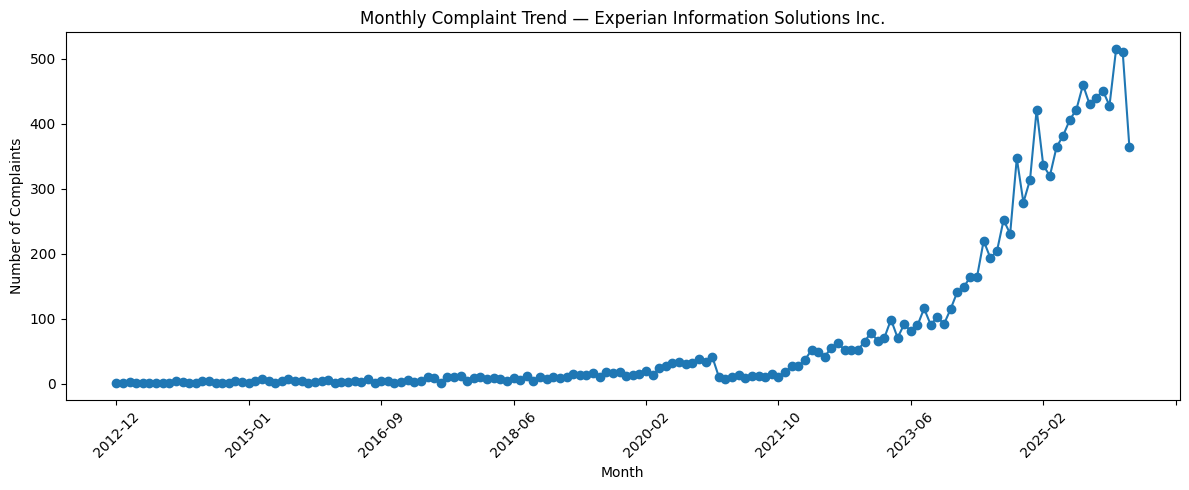

In [22]:
monthly_trend = company_analysis["monthly_trend"]

plt.figure(figsize=(12, 5))
monthly_trend.plot(kind="line", marker="o")

plt.title(f"Monthly Complaint Trend — {company_name}")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
def format_company_statistics(company_analysis):
    top_products_text = "\n".join(
        [
            f"- {product}: {count}"
            for product, count
            in company_analysis["top_products"].items()
        ]
    )

    top_issues_text = "\n".join(
        [
            f"- {issue}: {count}"
            for issue, count
            in company_analysis["top_issues"].items()
        ]
    )

    return f"""
Company: {company_analysis["company"]}

Total complaints:
{company_analysis["total_complaints"]}

Complaint narratives available:
{company_analysis["narratives_available"]}

Timely response rate:
{company_analysis["timely_response_rate"]}%

Top products:
{top_products_text}

Top complaint issues:
{top_issues_text}
"""

In [24]:
statistics_text = format_company_statistics(
    company_analysis
)

print(statistics_text)


Company: Experian Information Solutions Inc.

Total complaints:
11620

Complaint narratives available:
2659

Timely response rate:
100.0%

Top products:
- Credit reporting or other personal consumer reports: 9137
- Credit reporting, credit repair services, or other personal consumer reports: 2089
- Debt collection: 162
- Credit reporting: 152
- Credit card: 60

Top complaint issues:
- Incorrect information on your report: 6202
- Improper use of your report: 2621
- Problem with a company's investigation into an existing problem: 1789
- Problem with a credit reporting company's investigation into an existing problem: 549
- Incorrect information on credit report: 108



In [25]:
def generate_business_insights(company_analysis):

    statistics = format_company_statistics(company_analysis)

    messages = [
        {
            "role": "system",
            "content": (
                "You are a senior business consultant preparing a report "
                "for executive management. "
                "Use only the statistics provided. "
                "Do not invent any numbers."
            ),
        },
        {
            "role": "user",
            "content": f"""
The following customer complaint statistics are available.

{statistics}

Generate a professional report with these sections:

1. Executive Summary
2. Key Findings
3. Business Risks
4. Recommended Actions
5. Conclusion

Keep the report concise and professional.
"""
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    response = generator(
        prompt,
        max_new_tokens=500,
        do_sample=False,
        return_full_text=False
    )

    return response[0]["generated_text"]

In [26]:
business_report = generate_business_insights(
    company_analysis
)

print(business_report)

[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


### Report to Executive Management

#### 1. Executive Summary
This report summarizes key findings from Experian Information Solutions Inc.'s customer complaint data. The company received a total of 11,620 complaints, with a timely response rate of 100%. The top products include credit reporting and related services, while the most common complaint issues involve incorrect information on credit reports and improper use of consumer reports.

#### 2. Key Findings
- **Total Complaints:** 11,620
- **Complaint Narratives Available:** 2,659
- **Timely Response Rate:** 100%
- **Top Products:**
  - Credit reporting or other personal consumer reports: 9,137
  - Credit reporting, credit repair services, or other personal consumer reports: 2,089
  - Debt collection: 162
  - Credit reporting: 152
  - Credit card: 60
- **Top Complaint Issues:**
  - Incorrect information on your report: 6,202
  - Improper use of your report: 2,621
  - Problem with a company's investigation into an existing problem: 1

# Build the User Interface (Gradio)

In [34]:
import matplotlib.pyplot as plt
import pandas as pd


def create_top_issues_chart(company_analysis):
    top_issues = company_analysis["top_issues"].sort_values()

    fig, ax = plt.subplots(figsize=(10, 5))
    top_issues.plot(
        kind="barh",
        ax=ax,
    )

    ax.set_title("Top Complaint Issues")
    ax.set_xlabel("Number of Complaints")
    ax.set_ylabel("Issue")

    fig.tight_layout()

    return fig


def create_monthly_trend_chart(company_analysis):
    monthly_trend = company_analysis["monthly_trend"]

    fig, ax = plt.subplots(figsize=(11, 5))

    monthly_trend.plot(
        kind="line",
        marker="o",
        ax=ax,
    )

    ax.set_title("Monthly Complaint Trend")
    ax.set_xlabel("Month")
    ax.set_ylabel("Number of Complaints")
    ax.tick_params(axis="x", rotation=45)

    fig.tight_layout()

    return fig

In [35]:
def create_kpi_html(company_analysis):
    total_complaints = company_analysis["total_complaints"]
    narratives = company_analysis["narratives_available"]
    timely_rate = company_analysis["timely_response_rate"]

    top_issue = "Not available"
    if not company_analysis["top_issues"].empty:
        top_issue = company_analysis["top_issues"].index[0]

    return f"""
    <div class="kpi-grid">
        <div class="kpi-card">
            <div class="kpi-label">Total Complaints</div>
            <div class="kpi-value">{total_complaints:,}</div>
        </div>

        <div class="kpi-card">
            <div class="kpi-label">Narratives Available</div>
            <div class="kpi-value">{narratives:,}</div>
        </div>

        <div class="kpi-card">
            <div class="kpi-label">Timely Response Rate</div>
            <div class="kpi-value">{timely_rate:.1f}%</div>
        </div>

        <div class="kpi-card">
            <div class="kpi-label">Top Complaint Issue</div>
            <div class="kpi-value kpi-text">{top_issue}</div>
        </div>
    </div>
    """

In [36]:
def run_dashboard(company_name, narrative_limit):
    try:
        narrative_limit = int(narrative_limit)

        company_analysis = analyse_company(
            df,
            company_name,
        )

        complaints = get_complaints_by_company(
            df,
            company_name,
            limit=narrative_limit,
        )

        complaint_summary = summarize_complaints(
            company_name,
            complaints,
        )

        business_report = generate_business_insights(
            company_analysis,
        )

        kpi_html = create_kpi_html(
            company_analysis,
        )

        top_issues_chart = create_top_issues_chart(
            company_analysis,
        )

        monthly_trend_chart = create_monthly_trend_chart(
            company_analysis,
        )

        return (
            kpi_html,
            top_issues_chart,
            monthly_trend_chart,
            complaint_summary,
            business_report,
            "",
        )

    except Exception as error:
        return (
            "",
            None,
            None,
            "",
            "",
            f"Analysis failed: {error}",
        )

In [37]:
import gradio as gr

companies = sorted(
    df["Company"]
    .dropna()
    .unique()
    .tolist()
)

custom_css = """
.gradio-container {
    max-width: 1400px !important;
    margin: auto !important;
}

.dashboard-title {
    text-align: center;
    margin-bottom: 0;
}

.dashboard-subtitle {
    text-align: center;
    color: #666;
    margin-top: 4px;
    margin-bottom: 24px;
}

.kpi-grid {
    display: grid;
    grid-template-columns: repeat(4, minmax(0, 1fr));
    gap: 16px;
    margin: 10px 0 22px 0;
}

.kpi-card {
    background: white;
    border: 1px solid #e5e7eb;
    border-radius: 12px;
    padding: 18px;
    min-height: 110px;
    box-shadow: 0 2px 8px rgba(0, 0, 0, 0.05);
}

.kpi-label {
    color: #6b7280;
    font-size: 14px;
    margin-bottom: 10px;
}

.kpi-value {
    font-size: 28px;
    font-weight: 700;
    line-height: 1.2;
}

.kpi-text {
    font-size: 17px;
}

.section-heading {
    margin-top: 12px;
    margin-bottom: 8px;
}

@media (max-width: 900px) {
    .kpi-grid {
        grid-template-columns: repeat(2, minmax(0, 1fr));
    }
}
"""

with gr.Blocks(
    title="ComplaintIQ",
    css=custom_css,
) as demo:

    gr.Markdown(
        """
        # ComplaintIQ
        ### GenAI Customer Complaint Intelligence Platform
        """,
        elem_classes=[
            "dashboard-title",
            "dashboard-subtitle",
        ],
    )

    with gr.Row():
        with gr.Column(scale=3):
            company_dropdown = gr.Dropdown(
                choices=companies,
                value="Experian Information Solutions Inc.",
                label="Select Company",
                interactive=True,
            )

        with gr.Column(scale=1):
            narrative_slider = gr.Slider(
                minimum=5,
                maximum=20,
                step=5,
                value=10,
                label="Narratives to Analyse",
            )

        with gr.Column(scale=1):
            generate_button = gr.Button(
                "Generate Analysis",
                variant="primary",
            )

    status_output = gr.Markdown()

    gr.Markdown(
        "## Company Overview",
        elem_classes="section-heading",
    )

    kpi_output = gr.HTML()

    with gr.Row():
        top_issues_output = gr.Plot(
            label="Top Complaint Issues",
        )

        monthly_trend_output = gr.Plot(
            label="Monthly Complaint Trend",
        )

    with gr.Row():
        with gr.Column():
            gr.Markdown("## Complaint Narrative Summary")

            summary_output = gr.Markdown(
                value="Select a company and generate the analysis.",
            )

        with gr.Column():
            gr.Markdown("## Executive Business Report")

            report_output = gr.Markdown(
                value="The executive report will appear here.",
            )

    generate_button.click(
        fn=run_dashboard,
        inputs=[
            company_dropdown,
            narrative_slider,
        ],
        outputs=[
            kpi_output,
            top_issues_output,
            monthly_trend_output,
            summary_output,
            report_output,
            status_output,
        ],
    )

/tmp/ipykernel_536/1308693684.py:72: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(


In [38]:
demo.queue().launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b3b67b678f30f5fe1d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Project Conclusion

ComplaintIQ demonstrates how Generative AI can complement traditional data analytics in a customer complaint management workflow. The platform combines structured complaint analysis with qualitative narrative summarisation and executive reporting.

The project uses a real-world financial complaint dataset and runs entirely with free tools in Google Colab. Pandas provides reliable quantitative analysis, while Qwen2.5 generates grounded summaries, risks, and business recommendations. Gradio provides an interactive dashboard for company selection, KPI review, trend visualisation, and AI-assisted reporting.

In [39]:
sample_df = df.sample(
    n=min(5000, len(df)),
    random_state=42,
)

sample_path = "/content/complaints_sample_5000.csv"

sample_df.to_csv(
    sample_path,
    index=False,
)

print("Saved:", sample_path)
print("Shape:", sample_df.shape)

Saved: /content/complaints_sample_5000.csv
Shape: (5000, 21)


In [40]:
from google.colab import files

files.download(sample_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>